In [1]:
print("Phan Đức An - 6351071001")

Phan Đức An - 6351071001


## a) Đọc bộ dữ liệu train, test của MNIST từ Keras

In [2]:
# Import các thư viện cần thiết
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Đọc bộ dữ liệu MNIST
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

print("Đã đọc bộ dữ liệu MNIST thành công!")

Đã đọc bộ dữ liệu MNIST thành công!


## b) In ra kích thước của tập train, test

In [3]:
print("Kích thước tập train:")
print(f"  train_images: {train_images.shape}")
print(f"  train_labels: {train_labels.shape}")
print(f"\nKích thước tập test:")
print(f"  test_images: {test_images.shape}")
print(f"  test_labels: {test_labels.shape}")

print(f"\nSố lượng ảnh train: {train_images.shape[0]}")
print(f"Số lượng ảnh test: {test_images.shape[0]}")
print(f"Kích thước mỗi ảnh: {train_images.shape[1]}x{train_images.shape[2]} pixels")

Kích thước tập train:
  train_images: (60000, 28, 28)
  train_labels: (60000,)

Kích thước tập test:
  test_images: (10000, 28, 28)
  test_labels: (10000,)

Số lượng ảnh train: 60000
Số lượng ảnh test: 10000
Kích thước mỗi ảnh: 28x28 pixels


## c) Chuẩn hóa các giá trị pixel của ảnh về đoạn [0,1]

In [4]:
# Chuẩn hóa giá trị pixel về [0,1]
train_images = train_images / 255.0
test_images = test_images / 255.0

print("Dữ liệu sau khi chuẩn hóa:")
print(f"Min value: {train_images.min()}")
print(f"Max value: {train_images.max()}")

Dữ liệu sau khi chuẩn hóa:
Min value: 0.0
Max value: 1.0


## d) Định nghĩa hàm create_model

In [5]:
def create_model():
    """
    Tạo và biên dịch mô hình Neural Network cho MNIST
    """
    model = Sequential([
        # Flatten layer: Chuyển đổi từ 2D (28x28) thành 1D (784)
        Flatten(input_shape=(28, 28)),
        
        # Dense layer: 128 neurons, activation ReLU
        Dense(128, activation='relu'),
        
        # Dropout layer: 20% neurons bị tắt ngẫu nhiên
        Dropout(0.2),
        
        # Output layer: 10 neurons (0-9), activation Softmax
        Dense(10, activation='softmax')
    ])
    
    # Biên dịch mô hình
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Kiểm tra hàm create_model
print("Hàm create_model đã được định nghĩa!")
print("\nKiến trúc mô hình:")
test_model = create_model()
test_model.summary()

Hàm create_model đã được định nghĩa!

Kiến trúc mô hình:


c:\project\nop\Dataset\venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

## e) Huấn luyện mô hình bằng k-fold cross validation (k=10)

In [6]:
# Định nghĩa K-Fold Cross Validation
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

# Mảng lưu trữ kết quả
models = []
accuracy_per_fold = []
loss_per_fold = []

print("="*70)
print("BẮT ĐẦU HUẤN LUYỆN VỚI 10-FOLD CROSS VALIDATION")
print("="*70)

fold_no = 1
for train_index, val_index in kfold.split(train_images):
    print(f"\n{'='*70}")
    print(f"FOLD {fold_no}/10")
    print(f"{'='*70}")
    
    # Tạo mô hình mới cho mỗi fold
    model = create_model()
    
    # Chia dữ liệu train và validation cho fold hiện tại
    X_train_fold = train_images[train_index]
    X_val_fold = train_images[val_index]
    y_train_fold = train_labels[train_index]
    y_val_fold = train_labels[val_index]
    
    print(f"Train samples: {len(X_train_fold)}, Validation samples: {len(X_val_fold)}")
    
    # Huấn luyện mô hình
    history = model.fit(
        X_train_fold, y_train_fold,
        epochs=5,
        batch_size=32,
        validation_data=(X_val_fold, y_val_fold),
        verbose=1
    )
    
    # Lưu mô hình
    models.append(model)
    
    # Đánh giá mô hình trên tập validation
    scores = model.evaluate(X_val_fold, y_val_fold, verbose=0)
    loss = scores[0]
    accuracy = scores[1]
    
    # Lưu kết quả
    loss_per_fold.append(loss)
    accuracy_per_fold.append(accuracy)
    
    # In kết quả
    print(f"\n{'='*70}")
    print(f"KẾT QUẢ FOLD {fold_no}:")
    print(f"  - Loss: {loss:.4f}")
    print(f"  - Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"{'='*70}")
    
    fold_no += 1

print(f"\n{'='*70}")
print("HOÀN THÀNH K-FOLD CROSS VALIDATION")
print(f"{'='*70}")

BẮT ĐẦU HUẤN LUYỆN VỚI 10-FOLD CROSS VALIDATION

FOLD 1/10
Train samples: 54000, Validation samples: 6000
Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9095 - loss: 0.3089 - val_accuracy: 0.9593 - val_loss: 0.1438
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9552 - loss: 0.1511 - val_accuracy: 0.9697 - val_loss: 0.1033
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9662 - loss: 0.1127 - val_accuracy: 0.9752 - val_loss: 0.0890
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9718 - loss: 0.0923 - val_accuracy: 0.9780 - val_loss: 0.0751
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9753 - loss: 0.0794 - val_accuracy: 0.9777 - val_loss: 0.0792

KẾT QUẢ FOLD 1:
  - Loss: 0.0792
  - Accuracy: 0.9777 (97.77%)

FOLD 2/10
Train samples: 54000, Validation samples: 6000
Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9100 - loss: 0.3090 - val_accuracy: 0.9542 - val_loss: 0.154

## f) Tính Mean Accuracy, Std Accuracy, Mean Loss, Std Loss

In [7]:
# Tính các chỉ số thống kê
mean_accuracy = np.mean(accuracy_per_fold)
std_accuracy = np.std(accuracy_per_fold)
mean_loss = np.mean(loss_per_fold)
std_loss = np.std(loss_per_fold)

print("\n" + "="*70)
print("THỐNG KÊ KẾT QUẢ K-FOLD CROSS VALIDATION")
print("="*70)

print(f"\nAccuracy:")
print(f"  - Mean Accuracy: {mean_accuracy:.4f} ({mean_accuracy*100:.2f}%)")
print(f"  - Standard Deviation: {std_accuracy:.4f}")

print(f"\nLoss:")
print(f"  - Mean Loss: {mean_loss:.4f}")
print(f"  - Standard Deviation: {std_loss:.4f}")

print(f"\n{'='*70}")

# Hiển thị bảng kết quả từng fold
results_df = pd.DataFrame({
    'Fold': range(1, 11),
    'Accuracy': accuracy_per_fold,
    'Loss': loss_per_fold
})

print("\nKẾT QUẢ CHI TIẾT TỪNG FOLD:")
print(results_df.to_string(index=False))


THỐNG KÊ KẾT QUẢ K-FOLD CROSS VALIDATION

Accuracy:
  - Mean Accuracy: 0.9747 (97.47%)
  - Standard Deviation: 0.0023

Loss:
  - Mean Loss: 0.0861
  - Standard Deviation: 0.0062


KẾT QUẢ CHI TIẾT TỪNG FOLD:
 Fold  Accuracy     Loss
    1  0.977667 0.079174
    2  0.972333 0.087855
    3  0.976333 0.085410
    4  0.977000 0.079939
    5  0.971833 0.096936
    6  0.976333 0.083537
    7  0.970667 0.096870
    8  0.975167 0.086480
    9  0.974000 0.085385
   10  0.975500 0.079112


## g) Vẽ biểu đồ thể hiện accuracy và loss sau mỗi fold

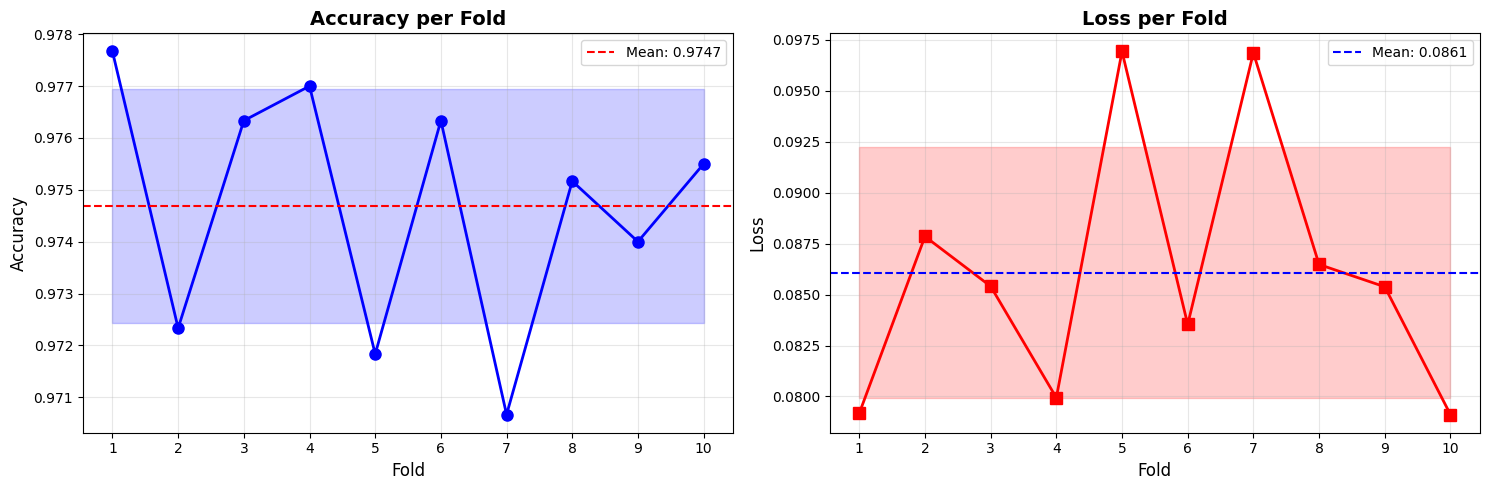

In [8]:
# Vẽ biểu đồ Accuracy và Loss
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

folds = range(1, 11)

# Biểu đồ Accuracy
axes[0].plot(folds, accuracy_per_fold, marker='o', linewidth=2, markersize=8, color='blue')
axes[0].axhline(y=mean_accuracy, color='r', linestyle='--', label=f'Mean: {mean_accuracy:.4f}')
axes[0].fill_between(folds, 
                      mean_accuracy - std_accuracy, 
                      mean_accuracy + std_accuracy, 
                      alpha=0.2, color='blue')
axes[0].set_xlabel('Fold', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Accuracy per Fold', fontsize=14, fontweight='bold')
axes[0].set_xticks(folds)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Biểu đồ Loss
axes[1].plot(folds, loss_per_fold, marker='s', linewidth=2, markersize=8, color='red')
axes[1].axhline(y=mean_loss, color='b', linestyle='--', label=f'Mean: {mean_loss:.4f}')
axes[1].fill_between(folds, 
                      mean_loss - std_loss, 
                      mean_loss + std_loss, 
                      alpha=0.2, color='red')
axes[1].set_xlabel('Fold', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Loss per Fold', fontsize=14, fontweight='bold')
axes[1].set_xticks(folds)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## h) Sử dụng mô hình có Accuracy tốt nhất để phân lớp tập test

In [9]:
# Tìm mô hình có accuracy tốt nhất
best_model_index = np.argmax(accuracy_per_fold)
best_model = models[best_model_index]
best_accuracy = accuracy_per_fold[best_model_index]
best_loss = loss_per_fold[best_model_index]

print("="*70)
print("MÔ HÌNH TỐT NHẤT")
print("="*70)
print(f"Fold: {best_model_index + 1}")
print(f"Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
print(f"Loss: {best_loss:.4f}")
print("="*70)

# Dự đoán cho tập test
y_pred_prob = best_model.predict(test_images)
y_pred = np.argmax(y_pred_prob, axis=1)

print(f"\nĐã dự đoán xong cho {len(y_pred)} ảnh trong tập test!")

MÔ HÌNH TỐT NHẤT
Fold: 1
Accuracy: 0.9777 (97.77%)
Loss: 0.0792
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 642us/step

Đã dự đoán xong cho 10000 ảnh trong tập test!


## i) Tính và in ra Accuracy của mô hình trên tập test

In [10]:
# Tính Accuracy trên tập test
test_accuracy = accuracy_score(test_labels, y_pred)

print("\n" + "="*70)
print("KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH TỐT NHẤT TRÊN TẬP TEST")
print("="*70)
print(f"\nAccuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Số lượng dự đoán đúng: {np.sum(y_pred == test_labels)}/{len(test_labels)}")
print(f"Số lượng dự đoán sai: {np.sum(y_pred != test_labels)}/{len(test_labels)}")


KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH TỐT NHẤT TRÊN TẬP TEST

Accuracy: 0.9763 (97.63%)
Số lượng dự đoán đúng: 9763/10000
Số lượng dự đoán sai: 237/10000


## j) Tính và in ra Precision, Recall, F1-score

In [11]:
# Classification Report
print("\nClassification Report:")
print("="*70)
print(classification_report(test_labels, y_pred, target_names=[str(i) for i in range(10)]))


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.98      0.99      0.99      1135
           2       0.97      0.98      0.97      1032
           3       0.96      0.99      0.97      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.97      0.97       892
           6       0.98      0.98      0.98       958
           7       0.98      0.97      0.97      1028
           8       0.98      0.96      0.97       974
           9       0.98      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



## k) Hiển thị confusion matrix bằng heat map

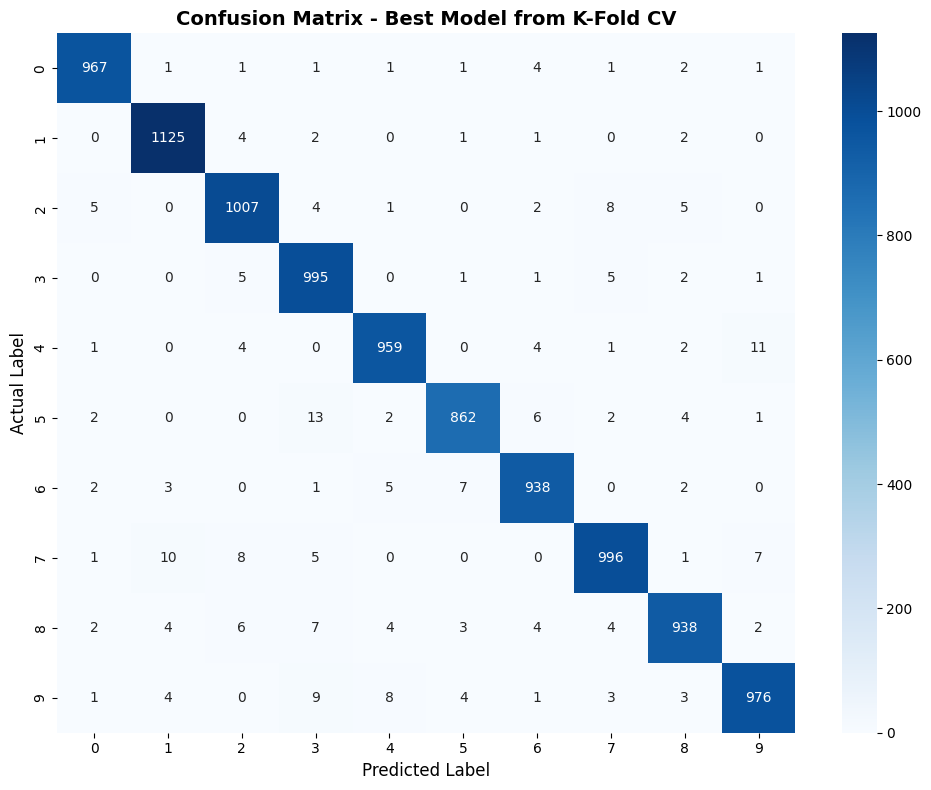


Phân tích Confusion Matrix:
Chữ số 0: 967/980 đúng (98.67%)
Chữ số 1: 1125/1135 đúng (99.12%)
Chữ số 2: 1007/1032 đúng (97.58%)
Chữ số 3: 995/1010 đúng (98.51%)
Chữ số 4: 959/982 đúng (97.66%)
Chữ số 5: 862/892 đúng (96.64%)
Chữ số 6: 938/958 đúng (97.91%)
Chữ số 7: 996/1028 đúng (96.89%)
Chữ số 8: 938/974 đúng (96.30%)
Chữ số 9: 976/1009 đúng (96.73%)


In [12]:
# Confusion Matrix
cm = confusion_matrix(test_labels, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), 
            yticklabels=range(10))
plt.title('Confusion Matrix - Best Model from K-Fold CV', fontsize=14, fontweight='bold')
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# Thống kê confusion matrix
print("\nPhân tích Confusion Matrix:")
print("="*70)
for i in range(10):
    total = np.sum(cm[i, :])
    correct = cm[i, i]
    accuracy_class = correct / total * 100
    print(f"Chữ số {i}: {correct}/{total} đúng ({accuracy_class:.2f}%)")

## l) In ra kết quả phân lớp của 5 ảnh đầu tiên trong tập test

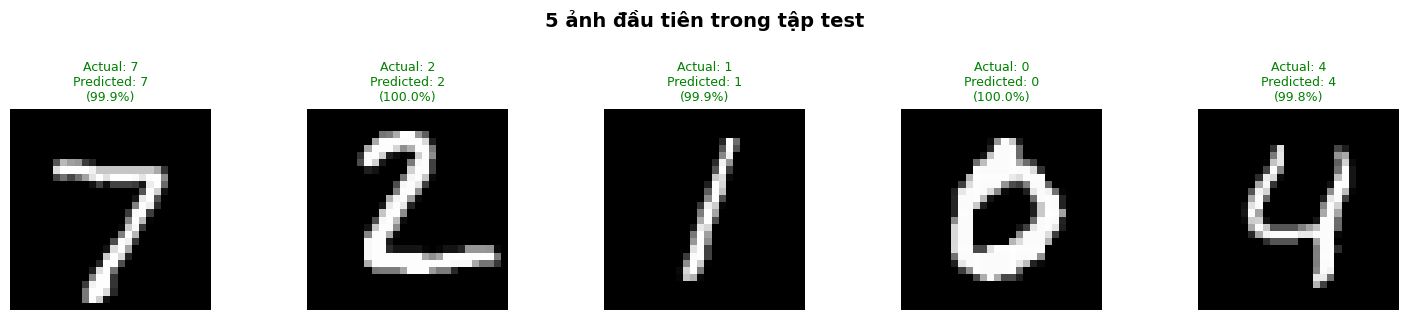


CHI TIẾT 5 ẢNH ĐẦU TIÊN

Ảnh 1:
  - Nhãn thực tế: 7
  - Dự đoán: 7
  - Độ tin cậy: 99.95%
  - Kết quả: ✓ ĐÚNG

Ảnh 2:
  - Nhãn thực tế: 2
  - Dự đoán: 2
  - Độ tin cậy: 99.97%
  - Kết quả: ✓ ĐÚNG

Ảnh 3:
  - Nhãn thực tế: 1
  - Dự đoán: 1
  - Độ tin cậy: 99.95%
  - Kết quả: ✓ ĐÚNG

Ảnh 4:
  - Nhãn thực tế: 0
  - Dự đoán: 0
  - Độ tin cậy: 99.97%
  - Kết quả: ✓ ĐÚNG

Ảnh 5:
  - Nhãn thực tế: 4
  - Dự đoán: 4
  - Độ tin cậy: 99.81%
  - Kết quả: ✓ ĐÚNG


In [13]:
# Hiển thị 5 ảnh đầu tiên và kết quả phân lớp
plt.figure(figsize=(15, 3))

for image_index in range(5):
    # Lấy ảnh từ tập test
    image = np.expand_dims(test_images[image_index], axis=0)
    
    # Dự đoán
    prediction_prob = best_model.predict(image, verbose=0)
    prediction = np.argmax(prediction_prob)
    confidence = np.max(prediction_prob) * 100
    
    # Hiển thị ảnh
    plt.subplot(1, 5, image_index + 1)
    plt.imshow(test_images[image_index], cmap='gray')
    plt.title(f'Actual: {test_labels[image_index]}\nPredicted: {prediction}\n({confidence:.1f}%)', 
              fontsize=9,
              color='green' if prediction == test_labels[image_index] else 'red')
    plt.axis('off')

plt.suptitle('5 ảnh đầu tiên trong tập test', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# In ra chi tiết
print("\n" + "="*70)
print("CHI TIẾT 5 ẢNH ĐẦU TIÊN")
print("="*70)
for i in range(5):
    image = np.expand_dims(test_images[i], axis=0)
    prediction_prob = best_model.predict(image, verbose=0)
    prediction = np.argmax(prediction_prob)
    confidence = np.max(prediction_prob) * 100
    
    status = "✓ ĐÚNG" if prediction == test_labels[i] else "✗ SAI"
    print(f"\nẢnh {i+1}:")
    print(f"  - Nhãn thực tế: {test_labels[i]}")
    print(f"  - Dự đoán: {prediction}")
    print(f"  - Độ tin cậy: {confidence:.2f}%")
    print(f"  - Kết quả: {status}")